In [40]:
import cv2
import numpy as np
import pandas as pd
import os

def process_kth_dataset_temporal(video_dir=r"C:\Users\subhe\OneDrive\Desktop\VL-JEPA\codes\VL-JEPA-base-CCTV\kth_videos", output_csv=r"C:\Users\subhe\OneDrive\Desktop\VL-JEPA\codes\VL-JEPA-base-CCTV\kth_temporal_features.csv"):
    print(f"Scanning directory {video_dir} for KTH videos...")
    if not os.path.exists(video_dir): 
        print(f"Directory not found: {video_dir}")
        return 0

    video_files = [f for f in os.listdir(video_dir) if f.endswith('.avi')]
    dataset_records = []
    label_to_id = {}
    current_class_id = 0

    for filename in video_files:
        action_label = filename.split('_')[1]
        if action_label not in label_to_id:
            label_to_id[action_label] = current_class_id
            current_class_id += 1

        target_class_id = label_to_id[action_label]
        video_path = os.path.join(video_dir, filename)
        cap = cv2.VideoCapture(video_path)

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total_frames < 20:
            cap.release()
            continue

        frames_to_sample = np.linspace(10, total_frames - 10, 5, dtype=int)
        
        # --- NEW: Initialize a list to hold the sequence of frames ---
        video_sequence = []

        for frame_idx in frames_to_sample:
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
            ret, frame = cap.read()
            if not ret: continue

            # Simulated CCTV Occlusion Mask
            cv2.rectangle(frame, (60, 40), (100, 80), (0, 0, 0), -1)

            # Resize to 16x16 but KEEP IT RGB (3 channels)
            small_frame = cv2.resize(frame, (16, 16), interpolation=cv2.INTER_AREA)
            small_frame = small_frame / 255.0
            
            # Append the 3D array (16, 16, 3) without flattening!
            video_sequence.append(small_frame.tolist())

        cap.release()

        # --- NEW: Save the entire sequence of 5 frames as ONE record ---
        if len(video_sequence) == 5:
            dataset_records.append({
                "video_file": filename,
                "target_class": target_class_id,
                "features": video_sequence # Shape will be (5, 16, 16, 3)
            })

    # Save to CSV
    df = pd.DataFrame(dataset_records)
    df.to_csv(output_csv, index=False)
    
    print("\n--- Temporal Extraction Complete! ---")
    print(f"Total video sequences processed: {len(df)}")
    print(f"Classes found: {label_to_id}")
    print(f"Saved dataset to {output_csv}")

    return len(label_to_id)

# Execute the extraction!
if __name__ == "__main__":
    process_kth_dataset_temporal()

Scanning directory C:\Users\subhe\OneDrive\Desktop\VL-JEPA\codes\VL-JEPA-base-CCTV\kth_videos for KTH videos...

--- Temporal Extraction Complete! ---
Total video sequences processed: 298
Classes found: {'boxing': 0, 'handclapping': 1, 'walking': 2}
Saved dataset to C:\Users\subhe\OneDrive\Desktop\VL-JEPA\codes\VL-JEPA-base-CCTV\kth_temporal_features.csv


# ==========================================
# 1.2. VISION ENCODER: V-JEPA Encoder
# ==========================================

In [43]:
import numpy as np

# ==========================================
# 1.2. VISION ENCODER: V-JEPA Encoder
# ==========================================
class NumPyVJEPAEncoder:

    def __init__(self,
                 frame_size=224,
                 patch_size=16,
                 frames=8,
                 embed_dim=256,
                 depth=4,
                 heads=4):

        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.frames = frames
        self.heads = heads
        self.head_dim = embed_dim // heads
        self.depth = depth

        patches_per_frame = (frame_size // patch_size) ** 2
        self.num_tokens = patches_per_frame * frames

        patch_dim = patch_size * patch_size * 3

        # patch projection
        self.W_patch = np.random.randn(patch_dim, embed_dim) / np.sqrt(patch_dim)

        # positional embedding (Spatio-temporal)
        self.pos_embed = np.random.randn(1, self.num_tokens, embed_dim) * 0.02

        # transformer weights
        self.Wq = [np.random.randn(embed_dim, embed_dim)/np.sqrt(embed_dim) for _ in range(depth)]
        self.Wk = [np.random.randn(embed_dim, embed_dim)/np.sqrt(embed_dim) for _ in range(depth)]
        self.Wv = [np.random.randn(embed_dim, embed_dim)/np.sqrt(embed_dim) for _ in range(depth)]
        self.Wo = [np.random.randn(embed_dim, embed_dim)/np.sqrt(embed_dim) for _ in range(depth)]

        self.W1 = [np.random.randn(embed_dim, embed_dim*4)/np.sqrt(embed_dim) for _ in range(depth)]
        self.W2 = [np.random.randn(embed_dim*4, embed_dim)/np.sqrt(embed_dim*4) for _ in range(depth)]

        # --- MODIFICATION: Learnable LayerNorm Parameters ---
        self.gamma1 = [np.ones(embed_dim) for _ in range(depth)]
        self.beta1 = [np.zeros(embed_dim) for _ in range(depth)]
        
        self.gamma2 = [np.ones(embed_dim) for _ in range(depth)]
        self.beta2 = [np.zeros(embed_dim) for _ in range(depth)]

    def gelu(self, x):
        return 0.5 * x * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715*x**3)))

    # --- MODIFICATION: Added gamma and beta ---
    def layer_norm(self, x, gamma, beta, eps=1e-5):
        mean = x.mean(axis=-1, keepdims=True)
        var = x.var(axis=-1, keepdims=True)
        return gamma * ((x - mean) / np.sqrt(var + eps)) + beta

    def softmax(self, x):
        x = x - np.max(x, axis=-1, keepdims=True)
        e = np.exp(x)
        return e / np.sum(e, axis=-1, keepdims=True)

    # --- MODIFICATION: Vectorized spatio-temporal patch extraction ---
    def extract_patches(self, video):
        # video shape: (B, T, H, W, C)
        B, T, H, W, C = video.shape
        p = self.patch_size

        # 1. Split each frame into a grid of patches
        # Shape becomes: (B, T, H_grid, p, W_grid, p, C)
        x = video.reshape(B, T, H // p, p, W // p, p, C)

        # 2. Transpose to group the spatial patch dimensions together
        # Shape becomes: (B, T, H_grid, W_grid, p_H, p_W, C)
        x = x.transpose(0, 1, 2, 4, 3, 5, 6)

        # 3. Flatten the spatio-temporal grid into a 1D sequence per batch, 
        # and flatten the pixels within each patch
        # Shape becomes: (B, T * H_grid * W_grid, p * p * C)
        num_patches_per_frame = (H // p) * (W // p)
        patches = x.reshape(B, T * num_patches_per_frame, p * p * C)

        # 4. Project to embedding dimension
        return patches @ self.W_patch

    def attention(self, x, layer):
        B, N, D = x.shape

        Q = x @ self.Wq[layer]
        K = x @ self.Wk[layer]
        V = x @ self.Wv[layer]

        Q = Q.reshape(B, N, self.heads, self.head_dim).transpose(0,2,1,3)
        K = K.reshape(B, N, self.heads, self.head_dim).transpose(0,2,1,3)
        V = V.reshape(B, N, self.heads, self.head_dim).transpose(0,2,1,3)

        scores = Q @ K.transpose(0,1,3,2) / np.sqrt(self.head_dim)
        attn = self.softmax(scores)

        out = attn @ V
        out = out.transpose(0,2,1,3).reshape(B,N,D)

        return out @ self.Wo[layer]

    def mlp(self, x, layer):
        return self.gelu(x @ self.W1[layer]) @ self.W2[layer]

    def forward(self, video):
        # patch embedding
        x = self.extract_patches(video)

        # add positional encoding
        x = x + self.pos_embed

        # transformer blocks
        for l in range(self.depth):
            norm1 = self.layer_norm(x, self.gamma1[l], self.beta1[l])
            x = x + self.attention(norm1, l)
            
            norm2 = self.layer_norm(x, self.gamma2[l], self.beta2[l])
            x = x + self.mlp(norm2, l)

        return x

# ==========================================
# 2. Y-Encoder: Self-Attention Text Encoder 
# ==========================================

In [44]:
import numpy as np

class BatchedSelfAttentionYEncoder:
    def __init__(self, vocab_size, max_seq_len, embed_dim, target_dim):
        np.random.seed(42) # Good for debugging, remove for actual training
        self.embed_dim = embed_dim
        self.d_k = embed_dim
        
        # Xavier/Glorot Initialization to prevent Softmax saturation
        self.token_embeddings = np.random.randn(vocab_size, embed_dim) / np.sqrt(embed_dim)
        self.position_embeddings = np.random.randn(max_seq_len, embed_dim) / np.sqrt(embed_dim)
        
        self.W_Q = np.random.randn(embed_dim, self.d_k) / np.sqrt(embed_dim)
        self.W_K = np.random.randn(embed_dim, self.d_k) / np.sqrt(embed_dim)
        self.W_V = np.random.randn(embed_dim, self.d_k) / np.sqrt(embed_dim)
        self.W_Output = np.random.randn(embed_dim, target_dim) / np.sqrt(embed_dim)

    def softmax(self, z):
        z = z - np.max(z, axis=-1, keepdims=True)
        exp_z = np.exp(z)
        return exp_z / np.sum(exp_z, axis=-1, keepdims=True)

    def get_sequence_embeddings(self, batched_token_indices):
        """
        NEW METHOD: Returns the unpooled sequence of query tokens.
        Inputs: batched_token_indices of shape (Batch, Seq_Length)
        Outputs: S_Q sequence of shape (Batch, Seq_Length, embed_dim)
        """
        B, seq_length = batched_token_indices.shape
        # Just grab the embeddings and add positional encoding
        X = self.token_embeddings[batched_token_indices] + self.position_embeddings[:seq_length]
        return X

    def encode(self, batched_token_indices):
        """
        Returns the POOLED target embedding S_Y.
        Inputs: batched_token_indices of shape (Batch, Seq_Length)
        Outputs: S_Y of shape (Batch, target_dim)
        """
        B, seq_length = batched_token_indices.shape
        
        # 1. Embeddings 
        X = self.token_embeddings[batched_token_indices] + self.position_embeddings[:seq_length]
        
        # 2. Linear Projections 
        Q = X @ self.W_Q
        K = X @ self.W_K
        V = X @ self.W_V
        
        # 3. Scaled Dot-Product Attention
        scores = (Q @ K.transpose(0, 2, 1)) / np.sqrt(self.d_k)
        attention_weights = self.softmax(scores)
        
        # 4. Contextual Embeddings
        contextual_embeddings = attention_weights @ V
        
        # 5. Sentence Representation via Mean Pooling
        sentence_representation = np.mean(contextual_embeddings, axis=1)
        
        # 6. Final Projection to Target Embedding space
        S_Y = sentence_representation @ self.W_Output
        
        return S_Y

# ==========================================
# 3. PREDICTOR: LLaMA-STYLE TRANSFORMER COMPONENTS
# ==========================================

In [45]:
import numpy as np

# ==========================================
# 3. PREDICTOR: LLaMA-STYLE TRANSFORMER COMPONENTS
# ==========================================
def stable_softmax(x, axis=-1):
    e_x = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e_x / e_x.sum(axis=axis, keepdims=True)

def sigmoid(x):
    x_clipped = np.clip(x, -500, 500)
    return 1.0 / (1.0 + np.exp(-x_clipped))

def silu(x): return x * sigmoid(x)

def silu_derivative(x):
    s = sigmoid(x)
    return s + x * s * (1.0 - s)

class NumPyRMSNorm:
    def __init__(self, embed_dim, learning_rate=0.001, eps=1e-6):
        self.eps, self.lr = eps, learning_rate
        self.gamma = np.ones((embed_dim,))
        self.cache = {}

    def forward(self, x):
        # x shape: (B, S, D)
        rms = np.sqrt(np.mean(x**2, axis=-1, keepdims=True) + self.eps)
        x_norm = x / rms
        out = self.gamma * x_norm
        self.cache = {'x': x, 'x_norm': x_norm, 'rms': rms}
        return out

    def backward(self, d_out):
        x, x_norm, rms = self.cache['x'], self.cache['x_norm'], self.cache['rms']
        N = x.shape[-1]
        
        # Sum across Batch and Sequence dimensions for gamma
        d_gamma = np.sum(d_out * x_norm, axis=(0, 1))
        d_x_norm = d_out * self.gamma
        d_rms = np.sum(d_x_norm * x * (-1.0 / (rms**2)), axis=-1, keepdims=True)
        d_x = (d_x_norm / rms) + (d_rms * x / (N * rms))
        
        self.gamma -= self.lr * d_gamma
        return d_x

class NumPyMultiHeadAttention:
    def __init__(self, embed_dim, num_heads, learning_rate=0.001):
        self.embed_dim, self.num_heads, self.lr = embed_dim, num_heads, learning_rate
        self.head_dim = embed_dim // num_heads
        
        self.W_q = np.random.randn(embed_dim, embed_dim) * np.sqrt(2. / embed_dim)
        self.W_k = np.random.randn(embed_dim, embed_dim) * np.sqrt(2. / embed_dim)
        self.W_v = np.random.randn(embed_dim, embed_dim) * np.sqrt(2. / embed_dim)
        self.W_o = np.random.randn(embed_dim, embed_dim) * np.sqrt(2. / embed_dim)
        self.cache = {}

    def forward(self, x):
        B, seq_len, D = x.shape
        Q_full, K_full, V_full = x @ self.W_q, x @ self.W_k, x @ self.W_v
        
        Q = Q_full.reshape(B, seq_len, self.num_heads, self.head_dim).transpose(0, 2, 1, 3)
        K = K_full.reshape(B, seq_len, self.num_heads, self.head_dim).transpose(0, 2, 1, 3)
        V = V_full.reshape(B, seq_len, self.num_heads, self.head_dim).transpose(0, 2, 1, 3)
        
        scores = (Q @ K.transpose(0, 1, 3, 2)) / np.sqrt(self.head_dim)
        attention_weights = stable_softmax(scores, axis=-1)
        
        context_output = attention_weights @ V
        context_output_flat = context_output.transpose(0, 2, 1, 3).reshape(B, seq_len, self.embed_dim)
        final_output = context_output_flat @ self.W_o
        
        self.cache = {'x': x, 'Q': Q, 'K': K, 'V': V, 'aw': attention_weights, 'co_flat': context_output_flat}
        return final_output

    def backward(self, d_out):
        x, Q, K, V = self.cache['x'], self.cache['Q'], self.cache['K'], self.cache['V']
        aw, co_flat = self.cache['aw'], self.cache['co_flat']
        B, seq_len, D = x.shape

        # d_out shape: (B, S, D). Need to sum across B and S for weight updates
        # To do this cleanly: flatten B and S when multiplying with inputs
        x_flat = x.reshape(-1, D)
        d_out_flat = d_out.reshape(-1, D)
        co_flat_reshaped = co_flat.reshape(-1, D)

        d_W_o = co_flat_reshaped.T @ d_out_flat
        d_context_flat = d_out @ self.W_o.T
        d_context = d_context_flat.reshape(B, seq_len, self.num_heads, self.head_dim).transpose(0, 2, 1, 3)

        d_V = aw.transpose(0, 1, 3, 2) @ d_context
        d_aw = d_context @ V.transpose(0, 1, 3, 2)
        
        d_scores = aw * (d_aw - np.sum(d_aw * aw, axis=-1, keepdims=True)) / np.sqrt(self.head_dim)

        d_Q = d_scores @ K
        d_K = d_scores.transpose(0, 1, 3, 2) @ Q

        d_Q_flat = d_Q.transpose(0, 2, 1, 3).reshape(-1, D)
        d_K_flat = d_K.transpose(0, 2, 1, 3).reshape(-1, D)
        d_V_flat = d_V.transpose(0, 2, 1, 3).reshape(-1, D)

        d_W_q = x_flat.T @ d_Q_flat
        d_W_k = x_flat.T @ d_K_flat
        d_W_v = x_flat.T @ d_V_flat
        
        d_x = (d_Q.transpose(0, 2, 1, 3).reshape(B, seq_len, D) @ self.W_q.T) + \
              (d_K.transpose(0, 2, 1, 3).reshape(B, seq_len, D) @ self.W_k.T) + \
              (d_V.transpose(0, 2, 1, 3).reshape(B, seq_len, D) @ self.W_v.T)

        self.W_q -= self.lr * d_W_q
        self.W_k -= self.lr * d_W_k
        self.W_v -= self.lr * d_W_v
        self.W_o -= self.lr * d_W_o
        return d_x

class NumPySwiGLUFFN:
    def __init__(self, embed_dim, hidden_dim=None, learning_rate=0.001):
        self.embed_dim, self.lr = embed_dim, learning_rate
        self.hidden_dim = hidden_dim if hidden_dim else embed_dim * 4
        
        self.W_gate = np.random.randn(embed_dim, self.hidden_dim) * np.sqrt(2. / embed_dim)
        self.W_up = np.random.randn(embed_dim, self.hidden_dim) * np.sqrt(2. / embed_dim)
        self.W_down = np.random.randn(self.hidden_dim, embed_dim) * np.sqrt(2. / self.hidden_dim)
        self.cache = {}

    def forward(self, x):
        gate_proj, up_proj = x @ self.W_gate, x @ self.W_up
        activated_gate = silu(gate_proj)
        mid_representation = activated_gate * up_proj
        out = mid_representation @ self.W_down
        
        self.cache = {'x': x, 'gate_proj': gate_proj, 'up_proj': up_proj, 'activated_gate': activated_gate, 'mid': mid_representation}
        return out

    def backward(self, d_out):
        x, gate_proj, up_proj = self.cache['x'], self.cache['gate_proj'], self.cache['up_proj']
        activated_gate, mid = self.cache['activated_gate'], self.cache['mid']
        
        x_flat = x.reshape(-1, x.shape[-1])
        d_out_flat = d_out.reshape(-1, d_out.shape[-1])
        mid_flat = mid.reshape(-1, mid.shape[-1])

        d_W_down = mid_flat.T @ d_out_flat
        d_mid = d_out @ self.W_down.T 
        
        d_activated_gate = d_mid * up_proj
        d_up_proj = d_mid * activated_gate
        d_W_up = x_flat.T @ d_up_proj.reshape(-1, d_up_proj.shape[-1])
        
        d_gate_proj = d_activated_gate * silu_derivative(gate_proj)
        d_W_gate = x_flat.T @ d_gate_proj.reshape(-1, d_gate_proj.shape[-1])
        
        d_x = (d_gate_proj @ self.W_gate.T) + (d_up_proj @ self.W_up.T)
        
        self.W_gate -= self.lr * d_W_gate
        self.W_up -= self.lr * d_W_up
        self.W_down -= self.lr * d_W_down
        return d_x

class NumPyTransformerBlock:
    def __init__(self, embed_dim, num_heads, hidden_dim=None, learning_rate=0.001):
        self.norm1 = NumPyRMSNorm(embed_dim, learning_rate)
        self.attn = NumPyMultiHeadAttention(embed_dim, num_heads, learning_rate)
        self.norm2 = NumPyRMSNorm(embed_dim, learning_rate)
        self.ffn = NumPySwiGLUFFN(embed_dim, hidden_dim, learning_rate)

    def forward(self, x):
        x_mid = x + self.attn.forward(self.norm1.forward(x))
        return x_mid + self.ffn.forward(self.norm2.forward(x_mid))

    def backward(self, d_out):
        d_x_mid = d_out + self.norm1.backward(self.attn.backward(self.norm2.backward(self.ffn.backward(d_out))))
        return d_x_mid

# --- The Batched Predictor with Projection Head ---
class NumPyVLJEPAPredictor:
    def __init__(self, embed_dim, target_dim, num_heads, num_layers=2, hidden_dim=None, lr=0.001):
        self.embed_dim, self.lr = embed_dim, lr
        self.blocks = [NumPyTransformerBlock(embed_dim, num_heads, hidden_dim, lr) for _ in range(num_layers)]
        
        # --- MODIFICATION: Final Projection to match Y-Encoder space ---
        self.W_proj = np.random.randn(embed_dim, target_dim) / np.sqrt(embed_dim)
        self.cache = {}

    def forward(self, S_v, S_q):
        # S_v shape: (B, seq_len_v, D)
        # S_q shape: (B, seq_len_q, D)
        seq_len_v, seq_len_q = S_v.shape[1], S_q.shape[1]
        
        # Concatenate along the sequence dimension (axis=1)
        H = np.concatenate((S_v, S_q), axis=1) 
        
        for block in self.blocks:
            H = block.forward(H)
            
        # Isolate the query tokens for pooling
        H_q_out = H[:, seq_len_v:, :] 
        
        # Mean pool across the sequence dimension
        # Shape becomes (B, D)
        pooled_output = np.mean(H_q_out, axis=1) 
        
        # Project to target space
        S_y_hat = pooled_output @ self.W_proj
        
        self.cache = {'seq_len_v': seq_len_v, 'seq_len_q': seq_len_q, 'pooled_output': pooled_output}
        return S_y_hat

    def backward(self, d_S_y_hat):
        seq_len_v, seq_len_q = self.cache['seq_len_v'], self.cache['seq_len_q']
        pooled_output = self.cache['pooled_output']
        
        # Backprop through Projection Head
        d_W_proj = pooled_output.T @ d_S_y_hat
        d_pooled_output = d_S_y_hat @ self.W_proj.T
        self.W_proj -= self.lr * d_W_proj
        
        # Backprop through Pooling (distribute gradient across sequence)
        # Reshape to (B, 1, D) and repeat to (B, seq_len_q, D)
        d_H_q_out = np.repeat(np.expand_dims(d_pooled_output / seq_len_q, axis=1), seq_len_q, axis=1)
        
        # Visual tokens get zero gradient from the direct output pool, 
        # but they will get gradients flowing backwards through the attention layers.
        B = d_H_q_out.shape[0]
        d_H_v_out = np.zeros((B, seq_len_v, self.embed_dim))
        
        d_H = np.concatenate((d_H_v_out, d_H_q_out), axis=1)
        
        for block in reversed(self.blocks):
            d_H = block.backward(d_H)
            
        # Split gradients back for S_v and S_q
        return d_H[:, :seq_len_v, :], d_H[:, seq_len_v:, :]

# ==========================================
# 4. InfoNCE Contrastive Loss
# ==========================================

In [46]:
import numpy as np

# ==========================================
# 4. InfoNCE Contrastive Loss
# ==========================================
class BiDirectionalInfoNCELoss:
    def __init__(self, temperature=0.1):
        self.tau = temperature
        self.cache = {}

    def forward(self, S_y_hat, S_y):
        """
        Inputs: 
        S_y_hat: Predicted embeddings from Predictor, shape (B, D)
        S_y: Target embeddings from Y-Encoder, shape (B, D)
        """
        self.batch_size = S_y_hat.shape[0] # Fixed to axis=0 for batch size
        
        # 1. L2 Normalize predictions (P) and targets (T) along the feature dimension (axis=1)
        norm_P = np.linalg.norm(S_y_hat, axis=1, keepdims=True) + 1e-8
        norm_T = np.linalg.norm(S_y, axis=1, keepdims=True) + 1e-8
        
        P = S_y_hat / norm_P
        T = S_y / norm_T
        
        # 2. Cosine Similarity Matrix scaled by temperature
        # Shape: (B, D) @ (D, B) -> (B, B)
        logits = np.dot(P, T.T) / self.tau
        
        # 3. Bi-directional Softmax
        # P -> T (Predictor matching Target)
        exp_logits_v2t = np.exp(logits - np.max(logits, axis=1, keepdims=True))
        softmax_v2t = exp_logits_v2t / np.sum(exp_logits_v2t, axis=1, keepdims=True)
        
        # T -> P (Target matching Predictor)
        exp_logits_t2v = np.exp(logits.T - np.max(logits.T, axis=1, keepdims=True))
        softmax_t2v = exp_logits_t2v / np.sum(exp_logits_t2v, axis=1, keepdims=True)
        
        # 4. Calculate cross-entropy on the diagonal for both directions
        loss_v2t = -np.mean(np.log(np.diag(softmax_v2t) + 1e-8))
        loss_t2v = -np.mean(np.log(np.diag(softmax_t2v) + 1e-8))
        
        # Average the loss
        total_loss = (loss_v2t + loss_t2v) / 2.0
        
        self.cache = {
            'P': P, 'T': T, 
            'norm_P': norm_P, 'norm_T': norm_T,
            'softmax_v2t': softmax_v2t, 'softmax_t2v': softmax_t2v
        }
        
        return total_loss

    def backward(self):
        P, T = self.cache['P'], self.cache['T']
        norm_P, norm_T = self.cache['norm_P'], self.cache['norm_T']
        softmax_v2t, softmax_t2v = self.cache['softmax_v2t'], self.cache['softmax_t2v']
        
        # 1. Gradients of cross-entropy wrt logits for both directions
        d_logits_v2t = softmax_v2t.copy()
        np.fill_diagonal(d_logits_v2t, np.diag(d_logits_v2t) - 1.0)
        d_logits_v2t /= self.batch_size
        
        d_logits_t2v = softmax_t2v.copy()
        np.fill_diagonal(d_logits_t2v, np.diag(d_logits_t2v) - 1.0)
        d_logits_t2v /= self.batch_size
        
        # Combine gradients into the main (B, B) similarity matrix
        # Multiply by 0.5 because the forward pass averaged the two losses
        d_logits = 0.5 * d_logits_v2t + 0.5 * d_logits_t2v.T
        
        # 2. Gradients wrt normalized vectors P and T
        # d_logits is (B, B), T is (B, D) -> d_P is (B, D)
        d_P = np.dot(d_logits, T) / self.tau
        d_T = np.dot(d_logits.T, P) / self.tau
        
        # 3. Backpropagate through L2 normalization for P
        dot_dP_P = np.sum(d_P * P, axis=1, keepdims=True)
        d_S_y_hat = (d_P - P * dot_dP_P) / norm_P
        
        # 4. Backpropagate through L2 normalization for T
        dot_dT_T = np.sum(d_T * T, axis=1, keepdims=True)
        d_S_y = (d_T - T * dot_dT_T) / norm_T
        
        return d_S_y_hat, d_S_y

# ==========================================
# 5. UNIFIED BATCHED JEPA MODEL 
# ==========================================

In [47]:
import numpy as np

# ==========================================
#  UNIFIED BATCHED JEPA MODEL 
# ==========================================
class BatchedTransformerJEPA:
    def __init__(self, embed_dim, target_dim, text_encoder, vision_encoder, num_heads=4, num_layers=2, lr=0.01):
        self.lr = lr
        
        # Injecting our fully batched modules
        self.text_encoder = text_encoder
        self.vision_encoder = vision_encoder
        self.criterion = BiDirectionalInfoNCELoss(temperature=0.1)
        self.predictor = NumPyVLJEPAPredictor(embed_dim, target_dim, num_heads, num_layers, lr=lr)

    def forward(self, video_batch, batched_text_query, batched_text_target):
        """
        video_batch: (B, T, H, W, C)
        batched_text_query: (B, Seq_Q) - indices
        batched_text_target: (B, Seq_Y) - indices
        """
        
        # 1. Vision Forward (Batched)
        # Returns the full sequence of spatio-temporal tokens: (B, Seq_V, embed_dim)
        self.S_v = self.vision_encoder.forward(video_batch) 
        
        # 2. Target Text Forward (Batched & Pooled)
        # The target must be a single condensed embedding per batch item: (B, target_dim)
        self.S_y = self.text_encoder.encode(batched_text_target) 
        
        # 3. Query Text Forward (Batched & UNPOOLED)
        # The Predictor needs the sequence of query tokens to attend to: (B, Seq_Q, embed_dim)
        # (Assuming you add a quick method to grab X before attention in the TextEncoder)
        self.S_q_seq = self.text_encoder.get_sequence_embeddings(batched_text_query) 
        
        # 4. Predictor Forward (Fully Vectorized!)
        # Predicts the target embedding: (B, target_dim)
        self.S_y_hat = self.predictor.forward(self.S_v, self.S_q_seq)
        
        # 5. Bi-Directional Contrastive Loss
        loss = self.criterion.forward(self.S_y_hat, self.S_y)
        return loss

    def backward(self):
        # 1. Get gradients from the Bi-Directional Loss
        # d_S_y_hat updates the Predictor/Vision
        # d_S_y updates the Target Text Encoder
        d_S_y_hat, d_S_y = self.criterion.backward()
        
        # 2. Backprop through the Predictor
        # Returns gradients for the visual tokens and the query tokens
        d_S_v, d_S_q_seq = self.predictor.backward(d_S_y_hat)
        
        # 3. Route gradients back to the encoders
        # Note: Writing the full backprop for the V-JEPA encoder in pure NumPy is a massive undertaking.
        # If your goal is just to train the Predictor, you can freeze the vision encoder.
        # Otherwise, you would call:
        # self.vision_encoder.backward(d_S_v)
        # self.text_encoder.backward(d_S_y, d_S_q_seq)
        
        return d_S_v, d_S_q_seq, d_S_y

# ==========================================
# 6. INFERENCE & TRAINING LOOP
# ==========================================

In [48]:
import numpy as np
import pandas as pd
import ast
import matplotlib.pyplot as plt

# ==========================================
# 6. INFERENCE & TRAINING LOOP
# ==========================================

def predict(model, feat_seq, num_classes, text_mapping, vocab):
    # 1. Format Vision Feature for the batch dimension: (Batch=1, Time=5, H=16, W=16, C=3)
    X_v = np.array(feat_seq).reshape(1, 5, 16, 16, 3)
    
    # 2. Architecturally Correct: Pass raw pixels through the Vision Encoder!
    S_v = model.vision_encoder.forward(X_v) 
    
    # 3. Format Query: "describe action" -> indices -> (1, Seq=2)
    query_indices = np.array([[vocab[w] for w in ["describe", "action"]]])
    S_q_seq = model.text_encoder.get_sequence_embeddings(query_indices)
    
    # 4. Predict Target Embedding
    S_y_hat = model.predictor.forward(S_v, S_q_seq) # Output: (1, target_dim)
    
    # 5. Zero-Shot Classification via Cosine Similarity
    distances = []
    for c in range(num_classes):
        target_indices = np.array([[vocab[w] for w in text_mapping[c]]])
        S_y = model.text_encoder.encode(target_indices) # Output: (1, target_dim)
        
        sim = np.dot(S_y_hat[0], S_y[0]) / (np.linalg.norm(S_y_hat[0]) * np.linalg.norm(S_y[0]) + 1e-8)
        distances.append(-sim) 
        
    return np.argmin(distances)

def run_training_and_plot(csv_path, epochs=400, batch_size=4, num_classes=3):
    print(f"Loading features from {csv_path}...")
    df = pd.read_csv(csv_path)
    feature_col = 'features' if 'features' in df.columns else 'hsv_features'
    df[feature_col] = df[feature_col].apply(ast.literal_eval)

    df_shuffled_full = df.sample(frac=1, random_state=42).reset_index(drop=True)
    split_idx = int(len(df_shuffled_full) * 0.8)
    train_df = df_shuffled_full.iloc[:split_idx].reset_index(drop=True)
    test_df = df_shuffled_full.iloc[split_idx:].reset_index(drop=True)

    text_mapping = {
        0: ["a", "person", "walking"],
        1: ["a", "person", "boxing"],
        2: ["a", "person", "clapping"]
    }

    all_words = ["describe", "action", "a", "person", "walking", "boxing", "clapping"]
    vocab = {word: idx for idx, word in enumerate(set(all_words))}
    vocab_size = len(vocab)

    # --- ARCHITECTURE SETUP ---
    embed_dim = 256
    target_dim = 64
    
    text_encoder = BatchedSelfAttentionYEncoder(vocab_size=vocab_size, max_seq_len=10, embed_dim=embed_dim, target_dim=target_dim)
    
    # NEW: Instantiate the V-JEPA encoder!
    # Frame is 16x16, let's use 4x4 patches. Over 5 frames, that yields 80 visual tokens.
    vision_encoder = NumPyVJEPAEncoder(frame_size=16, patch_size=4, frames=5, embed_dim=embed_dim, depth=2, heads=4)
    
    # NEW: Pass the vision_encoder into the main wrapper
    model = BatchedTransformerJEPA(
        embed_dim=embed_dim, 
        target_dim=target_dim, 
        text_encoder=text_encoder, 
        vision_encoder=vision_encoder, 
        num_heads=4, 
        num_layers=2, 
        lr=0.001 # Dropped LR slightly for smoother convergence
    )
    
    loss_history = []
    print(f"Starting VL-JEPA Predictor Training on {len(train_df)} samples...")

    for epoch in range(epochs):
        df_shuffled = train_df.sample(frac=1).reset_index(drop=True)
        epoch_loss = 0
        num_batches = 0

        for start_idx in range(0, len(train_df), batch_size):
            end_idx = min(start_idx + batch_size, len(train_df))
            batch_df = df_shuffled.iloc[start_idx:end_idx]
            if len(batch_df) < 2: continue 

            X_v_batch, text_query_batch, text_tokens_batch = [], [], []
            for _, row in batch_df.iterrows():
                X_v_batch.append(row[feature_col])
                text_query_batch.append([vocab[w] for w in ["describe", "action"]]) 
                text_tokens_batch.append([vocab[w] for w in text_mapping[int(row['target_class'])]])
                
            # --- NEW: Shape vision features to (Batch, Time, Height, Width, Channels) ---
            # Batch x 5 frames x 16 height x 16 width x 3 channels
            X_v_batch = np.array(X_v_batch).reshape(len(batch_df), 5, 16, 16, 3)
            
            text_query_batch = np.array(text_query_batch)
            text_tokens_batch = np.array(text_tokens_batch)

            # --- Fully Vectorized Forward & Backward Pass ---
            # Now X_v flows through the vision encoder to become S_v
            model.S_v = model.vision_encoder.forward(X_v_batch)
            
            model.S_y = model.text_encoder.encode(text_tokens_batch)
            model.S_q_seq = model.text_encoder.get_sequence_embeddings(text_query_batch)
            
            model.S_y_hat = model.predictor.forward(model.S_v, model.S_q_seq)
            loss = model.criterion.forward(model.S_y_hat, model.S_y)
            
            model.backward() 
            
            epoch_loss += loss
            num_batches += 1

        avg_loss = epoch_loss / num_batches
        loss_history.append(avg_loss)
        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs} | InfoNCE Loss: {avg_loss:.4f}")

    correct = sum([1 for _, row in test_df.iterrows() if predict(model, row[feature_col], num_classes, text_mapping, vocab) == int(row['target_class'])])
    print(f"\nTrue (Unseen) Accuracy: {(correct/len(test_df))*100:.2f}%")

    plt.figure(figsize=(8,4))
    plt.plot(loss_history, color='green')
    plt.title("VL-JEPA (Spatio-Temporal) Training Loss")
    plt.grid(True)
    plt.show()
    return model

Loading features from C:\Users\subhe\OneDrive\Desktop\VL-JEPA\codes\VL-JEPA-base-CCTV\kth_temporal_features.csv...
Starting VL-JEPA Predictor Training on 238 samples...
Epoch 1/400 | InfoNCE Loss: 1.3877
Epoch 5/400 | InfoNCE Loss: 1.3646
Epoch 10/400 | InfoNCE Loss: 1.3642
Epoch 15/400 | InfoNCE Loss: 1.3632
Epoch 20/400 | InfoNCE Loss: 1.3540
Epoch 25/400 | InfoNCE Loss: 1.3468
Epoch 30/400 | InfoNCE Loss: 1.3358
Epoch 35/400 | InfoNCE Loss: 1.3025
Epoch 40/400 | InfoNCE Loss: 1.2703
Epoch 45/400 | InfoNCE Loss: 1.2573
Epoch 50/400 | InfoNCE Loss: 1.2294
Epoch 55/400 | InfoNCE Loss: 1.1895
Epoch 60/400 | InfoNCE Loss: 1.1696
Epoch 65/400 | InfoNCE Loss: 1.1579
Epoch 70/400 | InfoNCE Loss: 1.1270
Epoch 75/400 | InfoNCE Loss: 1.0672
Epoch 80/400 | InfoNCE Loss: 1.1305
Epoch 85/400 | InfoNCE Loss: 1.1180
Epoch 90/400 | InfoNCE Loss: 1.0414
Epoch 95/400 | InfoNCE Loss: 1.0215
Epoch 100/400 | InfoNCE Loss: 1.0220
Epoch 105/400 | InfoNCE Loss: 1.0171
Epoch 110/400 | InfoNCE Loss: 1.0102
Ep

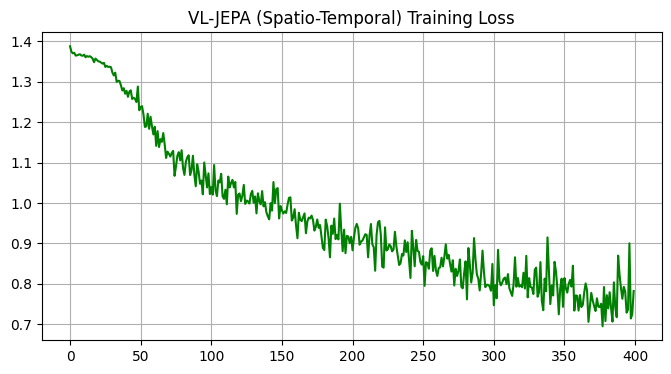

In [49]:
if __name__ == "__main__":
    # Point this to the NEW file generated by process_kth_dataset_temporal()
    csv_file = r"C:\Users\subhe\OneDrive\Desktop\VL-JEPA\codes\VL-JEPA-base-CCTV\kth_temporal_features.csv"
    
    trained_model = run_training_and_plot(csv_file, epochs=400, batch_size=4)

# ==========================================
# CONFUSION MATRIX
# ==========================================

Plotting confusion matrix for 60 unseen temporal test samples...


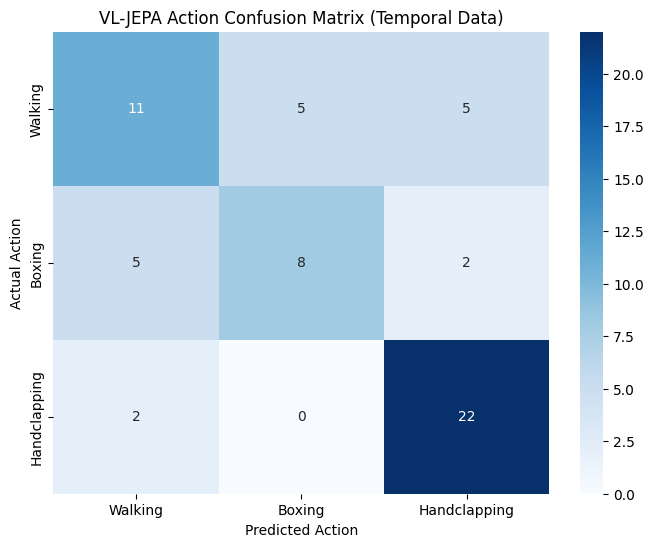

              precision    recall  f1-score   support

     Walking       0.61      0.52      0.56        21
      Boxing       0.62      0.53      0.57        15
Handclapping       0.76      0.92      0.83        24

    accuracy                           0.68        60
   macro avg       0.66      0.66      0.66        60
weighted avg       0.67      0.68      0.67        60



In [52]:
import numpy as np
import pandas as pd
import ast
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def plot_confusion_matrix(model, df_test, num_classes, label_names, text_mapping, vocab, feature_col='features'):
    y_true = []
    y_pred = []

    for _, row in df_test.iterrows():
        val = row[feature_col]
        # ast.literal_eval safely parses the nested list of the 5-frame sequence
        if isinstance(val, str):
            features = np.array(ast.literal_eval(val))
        else:
            features = np.array(val)
            
        true_label = int(row['target_class'])
        
        # Predict using the spatio-temporal sequence (5, 16, 16, 3)
        pred_label = predict(model, features, num_classes, text_mapping, vocab)

        y_true.append(true_label)
        y_pred.append(pred_label)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names)

    plt.title('VL-JEPA Action Confusion Matrix (Temporal Data)')
    plt.ylabel('Actual Action')
    plt.xlabel('Predicted Action')
    plt.show()

    print(classification_report(y_true, y_pred, target_names=label_names))

# ==========================================
# Execution
# ==========================================
if __name__ == "__main__":
    # Ensure this runs in the same script/notebook context as your training loop
    # so 'trained_model' and the 'predict' function are in memory.
    
    # --- UPDATE: Point to the NEW temporal features dataset ---
    df_eval = pd.read_csv(r"C:\Users\subhe\OneDrive\Desktop\VL-JEPA\codes\VL-JEPA-base-CCTV\kth_temporal_features.csv")

    feat_col = 'features' if 'features' in df_eval.columns else 'hsv_features'
    
    # REPLICATE THE MANUAL TRAIN/TEST SPLIT
    df_shuffled_full = df_eval.sample(frac=1, random_state=42).reset_index(drop=True)
    split_idx = int(len(df_shuffled_full) * 0.8)
    test_df = df_shuffled_full.iloc[split_idx:].reset_index(drop=True)

    labels = ["Walking", "Boxing", "Handclapping"]

    eval_text_mapping = {
        0: ["a", "person", "walking"],
        1: ["a", "person", "boxing"],
        2: ["a", "person", "clapping"]
    }

    # Recreate the vocabulary mapping used during training
    all_words = ["describe", "action", "a", "person", "walking", "boxing", "clapping"]
    eval_vocab = {word: idx for idx, word in enumerate(set(all_words))}

    print(f"Plotting confusion matrix for {len(test_df)} unseen temporal test samples...")
    # Pass eval_vocab into the plotter
    plot_confusion_matrix(trained_model, test_df, 3, labels, eval_text_mapping, eval_vocab, feature_col=feat_col)